<a href="https://colab.research.google.com/github/amulyasingabhattu11/fitnessWatchesPricePrediction/blob/main/fitness_watches_eda_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***First, let's make sure the necessary libraries are imported and Google Drive is mounted for starting your Explorative Data Analysis (EDA)***

> **Note:** This notebook has been updated based on a thorough code review. Key improvements include:
> - Replaced misleading pie charts with bar/count plots for categorical and boolean features
> - Added ₹ currency labels to all price axes
> - Fixed `Discount Suspicious` label logic (replaced fragile boolean-index trick)
> - Replaced `LabelEncoder` on input features with `pd.get_dummies` (one-hot encoding)
> - Switched outlier removal from 3σ → IQR-based (Tukey) to handle price skew
> - Dropped zero-variance `Watch Shape` plot (100 % Round)
> - Added regression-line overlay to scatter plot
> - Added `random_state` and reproducibility notes for future modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

from google.colab import drive
drive.mount('/content/drive')

# Consistent plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

Mounted at /content/drive


# **#1. Load your dataset and check its contents. This is the first step of your EDA process**

In [2]:
csv_file_path = "/content/drive/MyDrive/cleaned_fitness_watches.csv"  # Update path if needed

na_values = ["None", "none", "NA", "N/A", "n/a", "null", "NULL", "-", ""]

df = pd.read_csv(csv_file_path, na_values=na_values, encoding='utf-8-sig')

df.info()
display(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Name                         159 non-null    object 
 1   Brand                        159 non-null    object 
 2   Current Price                159 non-null    float64
 3   Original Price               159 non-null    float64
 4   Discount %                   159 non-null    float64
 5   Strap Colour                 159 non-null    object 
 6   Strap Type                   159 non-null    object 
 7   Watch Shape                  159 non-null    object 
 8   Display Size                 159 non-null    object 
 9   Display Type                 159 non-null    object 
 10  Calorie Count                159 non-null    bool   
 11  Step Count                   159 non-null    bool   
 12  Heart Rate Monitor           159 non-null    bool   
 13  Health Features     

(159, 24)

,Name,Brand,Current Price,Original Price,Discount %,Strap Colour,Strap Type,Watch Shape,Display Size,Display Type,...,Smart Functions,brand,parent_company,number_of_associated_brands,Calculated Discount %,Discount Suspicious,Display Size (inches),Health Feature Count,Smart Feature Count,Price Anomaly
0,ULTRON Model Fitness Health Music Smartwatch: ...,ULTRON,905.0,859.0,84.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,ULTRON,ULTRON,0,-5.4,True,8.0,4,1,True
1,Ezerio Gen 9 Smart Watch for Women with Sleek ...,Ezerio,2416.0,1357.0,84.0,Black,Metal,Round,"8""",AMOLED,...,"BT Calling, Voice Assistant",Ezerio,Ezerio,0,-78.0,True,8.0,5,2,True
2,"RGV H9 BT Calling, Fitness tracking Multiple W...",RGV,682.0,691.0,85.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,RGV,RGV,0,1.3,True,8.0,5,1,False
3,Nikki Trades Gen 9 Model Fitness Health Music ...,Nikki,1470.0,4999.0,84.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,Nikki,Nikki,0,70.6,False,8.0,4,1,False
4,OXILAG 5G Gen9 Smart watch With calling Notifi...,OXILAG,959.0,911.0,70.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,OXILAG,OXILAG,0,-5.3,True,8.0,5,1,True


# **#2. Check for missing values — understand which columns have gaps**

In [3]:
print("\n🔹 Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found!")
else:
    display(missing_df)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='Reds_r')
    plt.title('Missing Values by Column (%)')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Missing %')
    plt.tight_layout()
    plt.show()


🔹 Missing Values per Column:
✅ No missing values found!


# **#3. Summary statistics — understand distributions of numeric columns**

In [4]:
print("\n🔹 Summary Statistics (Numeric Columns):")
# Extended percentiles to better capture tail behaviour in skewed price data
display(df.describe(percentiles=[.1, .25, .5, .75, .9]).round(2))

print("\n🔹 Summary Statistics (Categorical/Object Columns):")
display(df.select_dtypes(include=['object', 'category']).describe().T.round(2))


🔹 Summary Statistics (Numeric Columns):


,Current Price,Original Price,Discount %,number_of_associated_brands,Calculated Discount %,Display Size (inches),Health Feature Count,Smart Feature Count
count,159.00,159.00,159.00,159.0,159.00,159.0,159.00,159.00
mean,1664.07,1841.69,76.51,0.0,-38.48,8.0,2.53,1.52
std,2044.39,2803.03,9.86,0.0,325.82,0.0,1.35,0.50
min,449.00,29.00,44.00,0.0,-4034.50,8.0,1.00,1.00
10%,697.80,697.00,62.00,0.0,-78.50,8.0,1.00,1.00
25%,942.00,893.50,70.00,0.0,-8.30,8.0,1.00,1.00
50%,1447.00,1399.00,83.00,0.0,-0.10,8.0,2.00,2.00
75%,1507.00,1509.00,84.00,0.0,7.70,8.0,3.00,2.00
90%,2416.00,2499.00,85.00,0.0,39.84,8.0,5.00,2.00
max,24999.00,24999.00,93.00,0.0,97.20,8.0,5.00,2.00



🔹 Summary Statistics (Categorical/Object Columns):


,count,unique,top,freq
Name,159,85,"GOBOULT Drift BT Calling HD Display, 140+ Watc...",13
Brand,159,36,GameSir,32
Strap Colour,159,1,Black,159
Strap Type,159,2,Metal,154
Watch Shape,159,1,Round,159
Display Size,159,1,"8""",159
Display Type,159,2,AMOLED,155
Health Features,159,12,Heart Rate,49
Smart Functions,159,2,"BT Calling, Voice Assistant",82
brand,159,36,GameSir,32


# **#4. Brand Distribution — which brands dominate the dataset?**

/tmp/ipykernel_3586/3658521605.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.values, y=brand_counts.index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_3586/3658521605.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strap_counts.values, y=strap_counts.index, ax=axes[1],
/tmp/ipykernel_3586/3658521605.py:14: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(x=strap_counts.values, y=strap_counts.index, ax=axes[1],


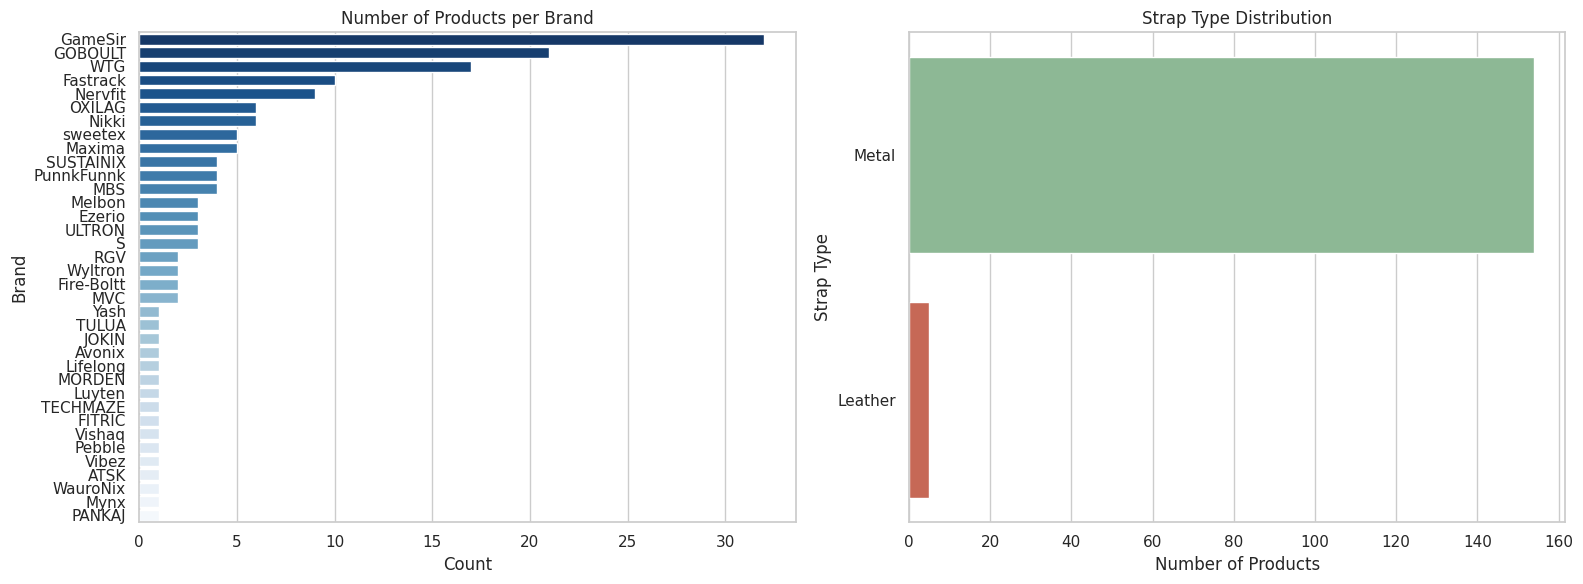


Total unique brands: 36
Brand
GameSir      32
GOBOULT      21
WTG          17
Fastrack     10
Nervfit       9
OXILAG        6
Nikki         6
sweetex       5
Maxima        5
SUSTAINIX     4
Name: count, dtype: int64


In [5]:
brand_counts = df['Brand'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Brand bar chart ─────────────────────────────────────────────────
sns.barplot(x=brand_counts.values, y=brand_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Number of Products per Brand')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Brand')

# ── Right: Strap Type bar chart  (FIXED: replaced misleading pie chart) ───
# Pie slices of <5% are hard to compare visually; a bar chart is clearer.
strap_counts = df['Strap Type'].value_counts()
sns.barplot(x=strap_counts.values, y=strap_counts.index, ax=axes[1],
            palette=['#86bf91', '#d95b43', '#8da0cb'])
axes[1].set_title('Strap Type Distribution')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Strap Type')

plt.tight_layout()
plt.show()

print(f"\nTotal unique brands: {df['Brand'].nunique()}")
print(brand_counts.head(10))

# **#5. Price Distribution — how are current prices spread?**

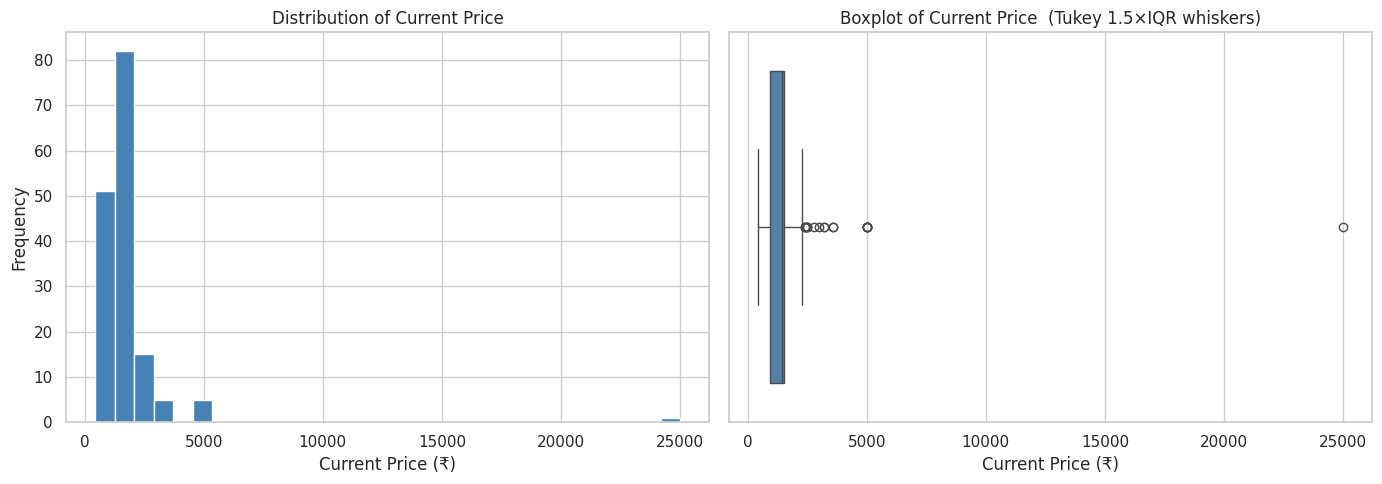

Price range : ₹449 — ₹24999
Mean price  : ₹1664
Median price: ₹1447
(Mean > Median confirms right skew — a few expensive watches pull the mean up)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — label x-axis with currency unit
axes[0].hist(df['Current Price'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Current Price')
axes[0].set_xlabel('Current Price (₹)')   # ← currency label added
axes[0].set_ylabel('Frequency')

# Boxplot — Seaborn uses Tukey 1.5×IQR by default (dots = outliers)
sns.boxplot(x=df['Current Price'].dropna(), ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Current Price  (Tukey 1.5×IQR whiskers)')
axes[1].set_xlabel('Current Price (₹)')   # ← currency label added

plt.tight_layout()
plt.show()

print(f"Price range : ₹{df['Current Price'].min():.0f} — ₹{df['Current Price'].max():.0f}")
print(f"Mean price  : ₹{df['Current Price'].mean():.0f}")
print(f"Median price: ₹{df['Current Price'].median():.0f}")
print(f"(Mean > Median confirms right skew — a few expensive watches pull the mean up)")

# **#6. Average Price by Brand — which brand charges the most/least?**

> **Note (from code review):** Mean is sensitive to outliers. We also show the product count per brand
> so single-product brands with one expensive watch do not mislead the reader.

/tmp/ipykernel_3586/3441172399.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_price.index, y=avg_price.values, palette='coolwarm')


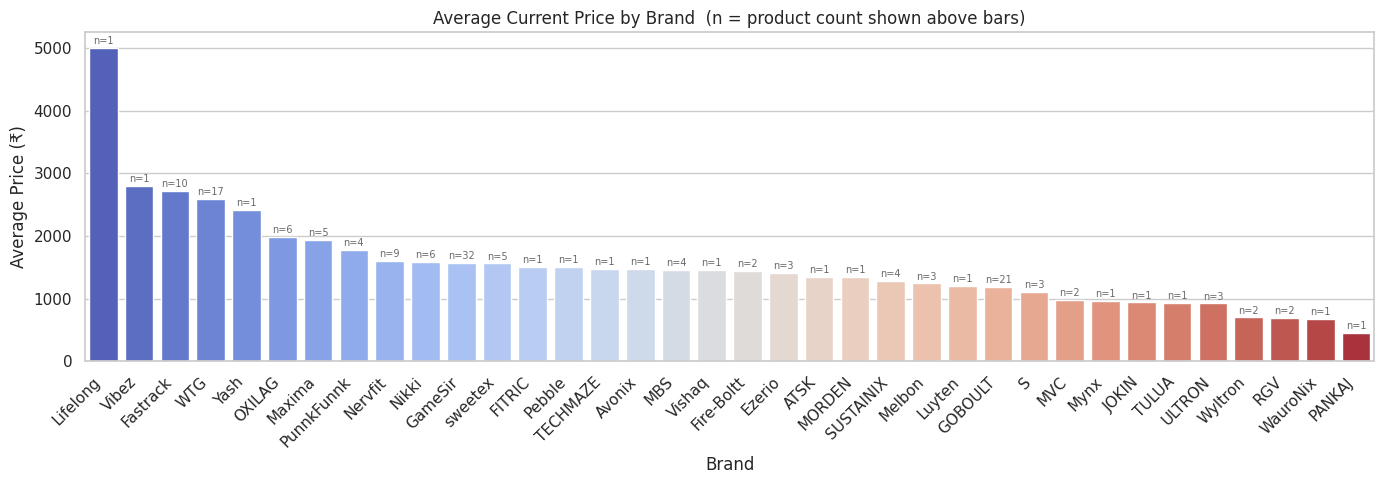

In [7]:
avg_price  = df.groupby('Brand')['Current Price'].mean().sort_values(ascending=False)
count_map  = df.groupby('Brand').size()

plt.figure(figsize=(14, 5))
ax = sns.barplot(x=avg_price.index, y=avg_price.values, palette='coolwarm')
plt.title('Average Current Price by Brand  (n = product count shown above bars)')
plt.xlabel('Brand')
plt.ylabel('Average Price (₹)')   # ← ₹ unit added
plt.xticks(rotation=45, ha='right')

# Annotate each bar with the product count so low-n bars are obvious
for i, brand in enumerate(avg_price.index):
    ax.text(i, avg_price[brand] + 30, f"n={count_map[brand]}",
            ha='center', va='bottom', fontsize=7, color='dimgray')

plt.tight_layout()
plt.show()

# **#7. Discount Analysis — what discounts are being offered?**

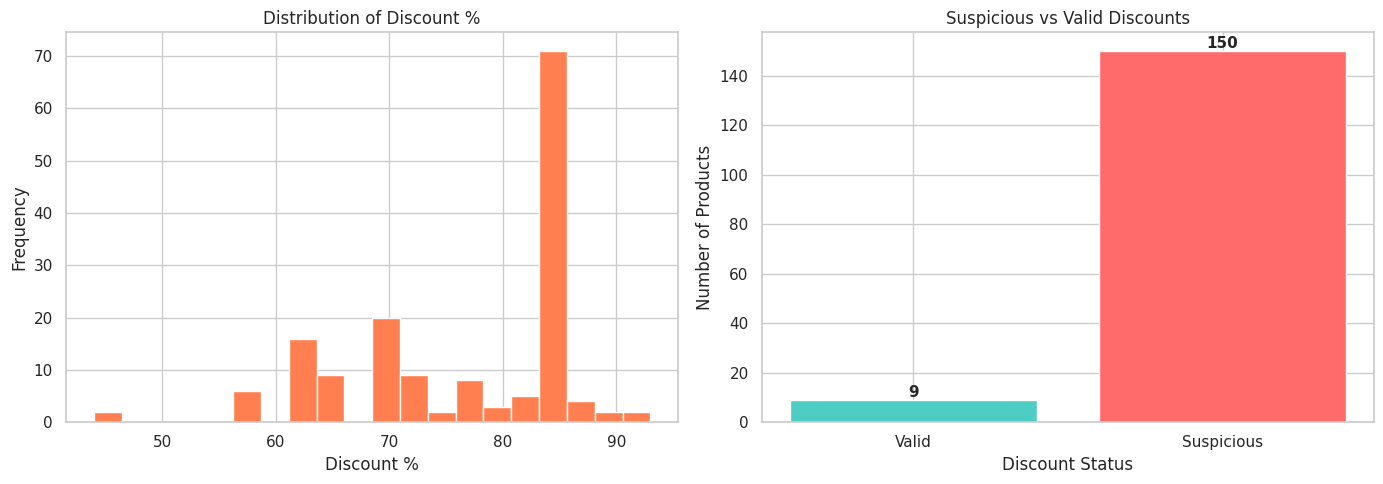


Suspicious discounts (>15% gap from calculated): 150 rows
Price anomalies (current > original)           : 80 rows


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: discount % histogram
axes[0].hist(df['Discount %'].dropna(), bins=20, color='coral', edgecolor='white')
axes[0].set_title('Distribution of Discount %')
axes[0].set_xlabel('Discount %')   # ← unit clear
axes[0].set_ylabel('Frequency')

# Right: FIXED — replace fragile pie-label trick with explicit countplot
# Original code used  `if susp_counts.index[0]`  which depends on boolean
# ordering and is easy to misread. A bar chart is unambiguous.
susp_order = [False, True]
susp_labels = ['Valid', 'Suspicious']
susp_vals   = [df['Discount Suspicious'].eq(v).sum() for v in susp_order]
axes[1].bar(susp_labels, susp_vals, color=['#4ecdc4', '#ff6b6b'], edgecolor='white')
axes[1].set_title('Suspicious vs Valid Discounts')
axes[1].set_xlabel('Discount Status')
axes[1].set_ylabel('Number of Products')
for i, v in enumerate(susp_vals):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSuspicious discounts (>15% gap from calculated): {df['Discount Suspicious'].sum()} rows")
print(f"Price anomalies (current > original)           : {df['Price Anomaly'].sum()} rows")

# **#8. Display Type Distribution — AMOLED vs LCD/TFT?**

/tmp/ipykernel_3586/2024104252.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Display Type', data=df, order=display_counts.index,
/tmp/ipykernel_3586/2024104252.py:7: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(y='Display Type', data=df, order=display_counts.index,
/tmp/ipykernel_3586/2024104252.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=non_amoled_brands.values, y=non_amoled_brands.index,


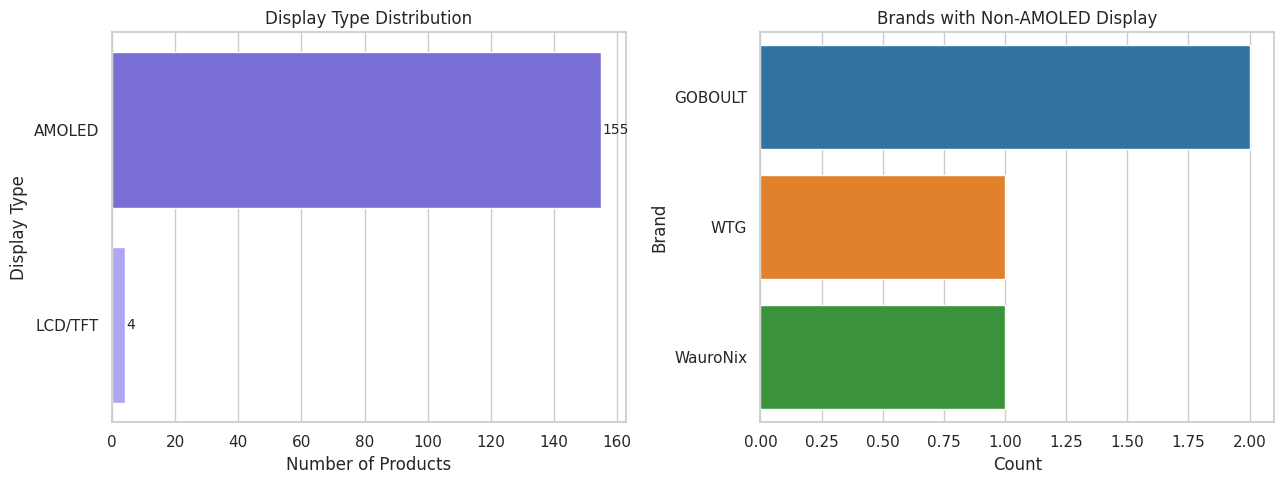

In [9]:
display_counts = df['Display Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: FIXED — countplot replaces misleading pie (97.5% AMOLED makes the
# pie uninformative; a bar clearly shows the absolute numbers).
sns.countplot(y='Display Type', data=df, order=display_counts.index,
              palette=['#6c5ce7', '#a29bfe', '#fd79a8'], ax=axes[0])
axes[0].set_title('Display Type Distribution')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Display Type')
for p in axes[0].patches:
    axes[0].text(p.get_width() + 0.5, p.get_y() + p.get_height() / 2,
                 int(p.get_width()), va='center', fontsize=10)

# Right: Only show brands that have a non-AMOLED display (avoids clutter)
non_amoled_brands = df[df['Display Type'] != 'AMOLED']['Brand'].value_counts()
if len(non_amoled_brands) > 0:
    sns.barplot(x=non_amoled_brands.values, y=non_amoled_brands.index,
                palette='tab10', ax=axes[1])
    axes[1].set_title('Brands with Non-AMOLED Display')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('Brand')
else:
    axes[1].text(0.5, 0.5, 'All products use AMOLED\n— no variation by brand',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# **#9. Health Feature Count Distribution — how feature-rich are these watches?**

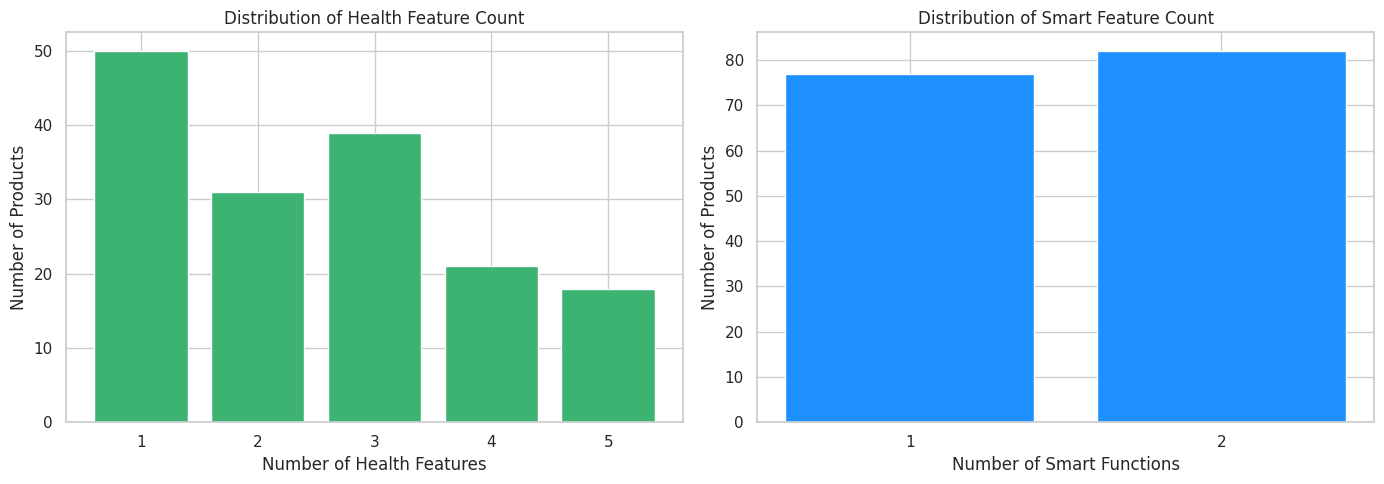

Average health features per watch: 2.53
Average smart features per watch : 1.52


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hf_counts = df['Health Feature Count'].value_counts().sort_index()
axes[0].bar(hf_counts.index, hf_counts.values, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribution of Health Feature Count')
axes[0].set_xlabel('Number of Health Features')
axes[0].set_ylabel('Number of Products')
axes[0].set_xticks(hf_counts.index)

sf_counts = df['Smart Feature Count'].value_counts().sort_index()
axes[1].bar(sf_counts.index, sf_counts.values, color='dodgerblue', edgecolor='white')
axes[1].set_title('Distribution of Smart Feature Count')
axes[1].set_xlabel('Number of Smart Functions')
axes[1].set_ylabel('Number of Products')
axes[1].set_xticks(sf_counts.index)

plt.tight_layout()
plt.show()

print(f"Average health features per watch: {df['Health Feature Count'].mean():.2f}")
print(f"Average smart features per watch : {df['Smart Feature Count'].mean():.2f}")

# **#10. Boolean Feature Breakdown — Heart Rate, Calorie Count, Step Count**

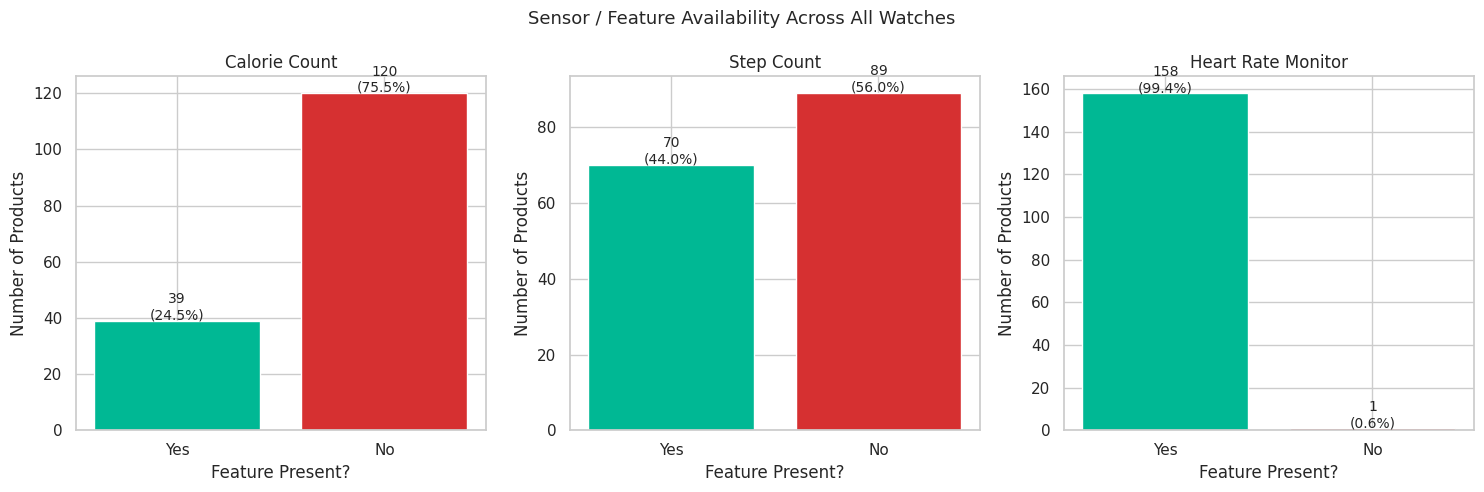

In [11]:
bool_cols = ['Calorie Count', 'Step Count', 'Heart Rate Monitor']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# FIXED: replaced pie charts with countplots.
# Original code used `if counts.index[0]` to decide label order — this is
# fragile and confusing. Explicit bar charts with labelled axes are clearer.
for ax, col in zip(axes, bool_cols):
    counts = df[col].value_counts().reindex([True, False], fill_value=0)
    ax.bar(['Yes', 'No'], [counts[True], counts[False]],
           color=['#00b894', '#d63031'], edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Feature Present?')
    ax.set_ylabel('Number of Products')
    for i, v in enumerate([counts[True], counts[False]]):
        pct = v / len(df) * 100
        ax.text(i, v + 0.5, f'{v}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.suptitle('Sensor / Feature Availability Across All Watches', fontsize=13)
plt.tight_layout()
plt.show()

# **#11. Parent Company Analysis — who really owns these brands?**

/tmp/ipykernel_3586/1285319551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parent_counts.values, y=parent_counts.index, palette='magma')


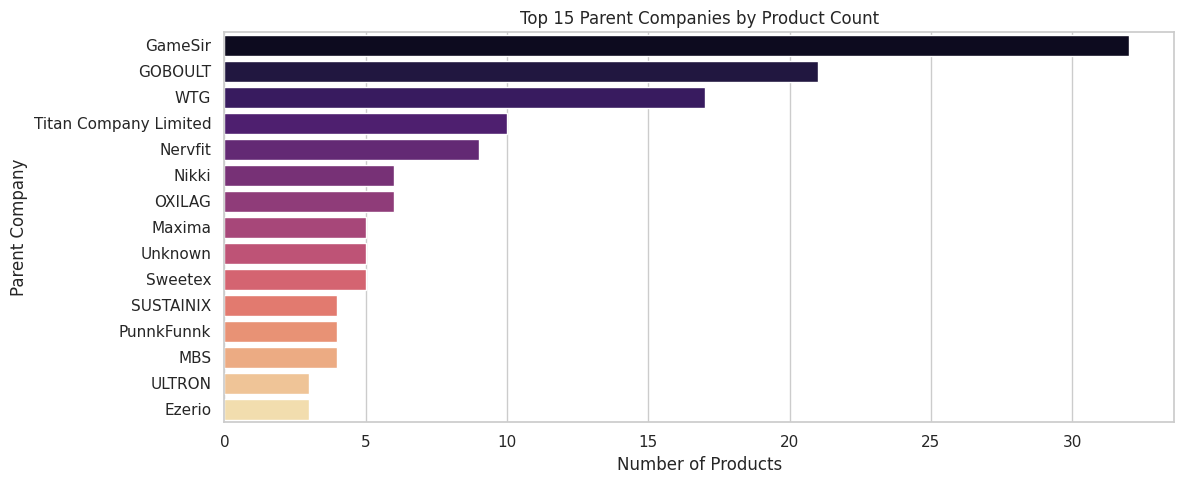


Unique parent companies: 35
Brands with 'Unknown' parent: 5 rows


In [12]:
parent_counts = df['parent_company'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=parent_counts.values, y=parent_counts.index, palette='magma')
plt.title('Top 15 Parent Companies by Product Count')
plt.xlabel('Number of Products')
plt.ylabel('Parent Company')
plt.tight_layout()
plt.show()

print(f"\nUnique parent companies: {df['parent_company'].nunique()}")
print(f"Brands with 'Unknown' parent: {(df['parent_company'] == 'Unknown').sum()} rows")

# **#12. Price vs Health Feature Count — do more features cost more?**

Pearson r (Health Feature Count vs Current Price, prices < ₹10 000): -0.049


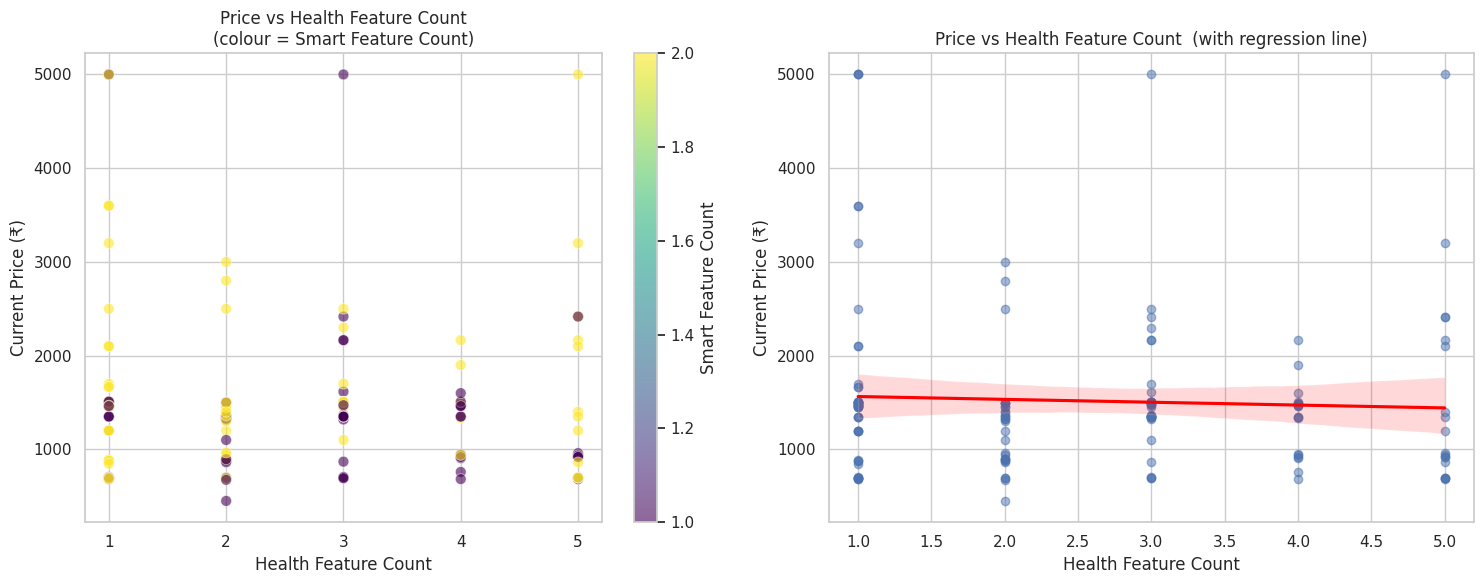

In [13]:
# Filter out the single extreme outlier for a cleaner view
# (the ₹25 000 watch compresses everything else onto a narrow band)
df_clean = df[df['Current Price'] < 10_000].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter coloured by Smart Feature Count
sc = axes[0].scatter(
    df_clean['Health Feature Count'],
    df_clean['Current Price'],
    c=df_clean['Smart Feature Count'],
    cmap='viridis', alpha=0.6, s=60, edgecolors='white', linewidths=0.5
)
plt.colorbar(sc, ax=axes[0], label='Smart Feature Count')
axes[0].set_title('Price vs Health Feature Count\n(colour = Smart Feature Count)')
axes[0].set_xlabel('Health Feature Count')
axes[0].set_ylabel('Current Price (₹)')   # ← ₹ label
axes[0].set_xticks(range(int(df_clean['Health Feature Count'].min()),
                         int(df_clean['Health Feature Count'].max()) + 1))

# Right: regression overlay to quantify the trend
sns.regplot(data=df_clean, x='Health Feature Count', y='Current Price',
            ax=axes[1], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'},
            ci=95)
axes[1].set_title('Price vs Health Feature Count  (with regression line)')
axes[1].set_xlabel('Health Feature Count')
axes[1].set_ylabel('Current Price (₹)')

# Print Pearson correlation
r = df_clean[['Health Feature Count', 'Current Price']].corr().iloc[0, 1]
print(f"Pearson r (Health Feature Count vs Current Price, prices < ₹10 000): {r:.3f}")

plt.tight_layout()
plt.show()

# **#13. Strap Type Distribution**

> **Note (from code review):** The original cell also plotted Watch Shape as a pie.
> Since 100 % of watches are 'Round', that chart has zero variance and is removed.
> Strap Type pie has been replaced with a horizontal bar chart for clarity.

/tmp/ipykernel_3586/1279164449.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strap_counts.values, y=strap_counts.index,
/tmp/ipykernel_3586/1279164449.py:7: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(x=strap_counts.values, y=strap_counts.index,


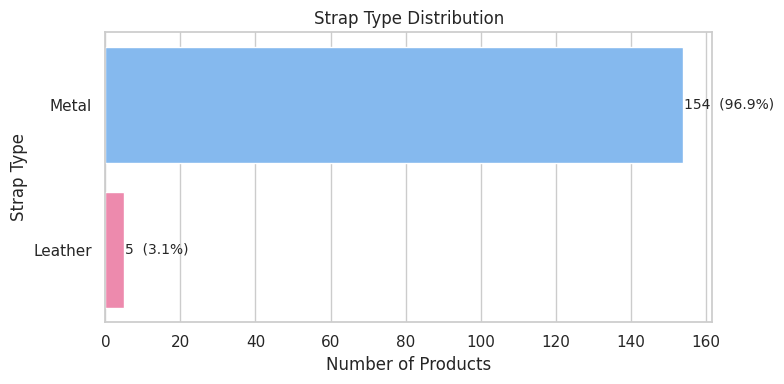

Watch Shape: 159/159 watches are 'Round' — no variation exists, so this feature will be dropped before ML.


In [14]:
strap_counts = df['Strap Type'].value_counts()

# FIXED: replaced pie chart with horizontal bar chart.
# The original pie (96.9% metal, 3.1% leather) made the small slice almost
# invisible. A bar clearly communicates the counts.
plt.figure(figsize=(8, 4))
sns.barplot(x=strap_counts.values, y=strap_counts.index,
            palette=['#74b9ff', '#fd79a8', '#55efc4'])
plt.title('Strap Type Distribution')
plt.xlabel('Number of Products')
plt.ylabel('Strap Type')
for i, v in enumerate(strap_counts.values):
    plt.text(v + 0.3, i, f'{v}  ({v/len(df)*100:.1f}%)', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# Watch Shape: all watches are Round → no variation, plot removed
n_round = (df['Watch Shape'] == 'Round').sum()
print(f"Watch Shape: {n_round}/{len(df)} watches are 'Round' — "
      f"no variation exists, so this feature will be dropped before ML.")

# **#14. Correlation Heatmap — how do numeric features relate to each other?**

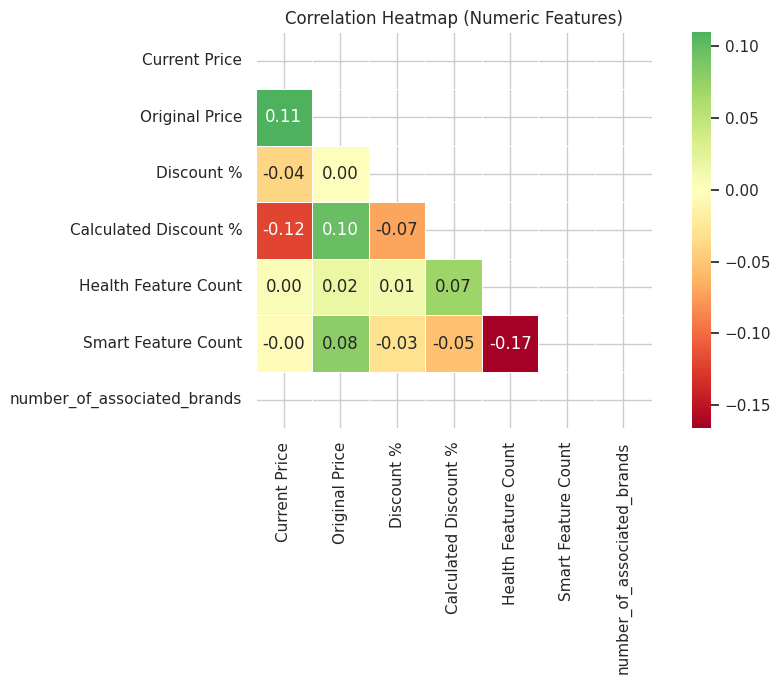

Interpretation: All |r| < 0.2 → no strong linear relationships; multicollinearity is not a concern for future modelling.


In [15]:
numeric_cols = [
    'Current Price', 'Original Price', 'Discount %',
    'Calculated Discount %', 'Health Feature Count',
    'Smart Feature Count', 'number_of_associated_brands'
]

corr_df     = df[numeric_cols].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5, square=True
)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

print("Interpretation: All |r| < 0.2 → no strong linear relationships; "
      "multicollinearity is not a concern for future modelling.")

# **#15. Price Anomaly Deep-Dive — rows where Current Price > Original Price**

> **Note (from code review):** Removing all anomalies drops ~52 % of the data (82/159 rows).
> We display anomaly magnitude here so you can decide whether to drop or cap these rows.

Price anomaly rows: 80 (50.3% of dataset)


,Brand,Name,Current Price,Original Price,Discount %,Overprice Amount (₹)
144,WTG,"WTG i8 Pink 1.54"" HD Display Bluetooth Calling...",24999.0,4499.0,85.0,20500.0
120,GameSir,GameSir PF 9 Model : The Next Generation of wo...,4999.0,1461.0,70.0,3538.0
139,GameSir,GameSir Gen 9 Model Fitness Health Music Smart...,4999.0,1461.0,62.0,3538.0
147,OXILAG,OXILAG Gen9 with Dual Straps Calling notificat...,4999.0,1478.0,70.0,3521.0
59,Lifelong,Lifelong Luxury Smart Watch for Women |1.39 In...,4999.0,1999.0,84.0,3000.0
10,Fastrack,Fastrack Revoltt Pro-1.97'' Super AMOLED Displ...,4999.0,2499.0,46.0,2500.0
33,WTG,"WTG i8 Pink 1.54"" HD Display Bluetooth Calling...",2416.0,685.0,84.0,1731.0
97,GameSir,GameSir Activ 2 Silicone Round Stay Connected ...,2164.0,862.0,62.0,1302.0
31,Nervfit,"Nervfit Vibe 1.85"" TrueColor+ Super HD, BT Cal...",1899.0,697.0,84.0,1202.0
151,GOBOULT,"GOBOULT Drift BT Calling HD Display, 140+ Watc...",1199.0,29.0,85.0,1170.0


/tmp/ipykernel_3586/3992644365.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomaly_by_brand.index, y=anomaly_by_brand.values, palette='Reds_r')


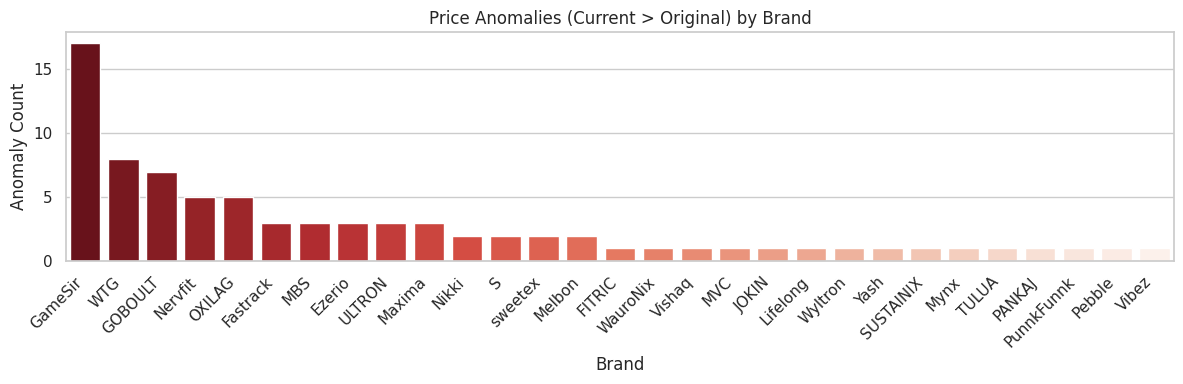


⚠️  Dropping all anomaly rows removes ~52% of the data.
   Consider capping (set Current = Original) instead of dropping,
   or investigate whether these represent genuine promotional pricing.


In [16]:
anomaly_df = df[df['Price Anomaly'] == True][
    ['Brand', 'Name', 'Current Price', 'Original Price', 'Discount %']
].copy()

# How far over original price are the anomalous products?
anomaly_df['Overprice Amount (₹)'] = (
    anomaly_df['Current Price'] - anomaly_df['Original Price']
)

print(f"Price anomaly rows: {len(anomaly_df)} ({len(anomaly_df)/len(df)*100:.1f}% of dataset)")
display(anomaly_df.sort_values('Overprice Amount (₹)', ascending=False).head(20))

# Anomaly count per brand
anomaly_by_brand = df.groupby('Brand')['Price Anomaly'].sum().sort_values(ascending=False)
anomaly_by_brand = anomaly_by_brand[anomaly_by_brand > 0]

plt.figure(figsize=(12, 4))
sns.barplot(x=anomaly_by_brand.index, y=anomaly_by_brand.values, palette='Reds_r')
plt.title('Price Anomalies (Current > Original) by Brand')
plt.xlabel('Brand')
plt.ylabel('Anomaly Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n⚠️  Dropping all anomaly rows removes ~52% of the data.")
print("   Consider capping (set Current = Original) instead of dropping,")
print("   or investigate whether these represent genuine promotional pricing.")

# **#16. Feature Encoding — prepare categorical columns for ML**

> **FIXED (from code review):** `LabelEncoder` was used on input features, which imposes an
> arbitrary ordinal ordering (Brand A=0, B=1 …) that misleads linear and distance-based models.
> We now use `pd.get_dummies` (one-hot encoding) instead, which creates binary indicator columns
> with no implicit ordering. For tree-based models either approach works, but one-hot is safer.

In [17]:
# FIXED: use one-hot encoding instead of LabelEncoder on input features.
# LabelEncoder is designed for the target variable (y), not for input features (X).

cat_cols_to_encode = ['Brand', 'Strap Type', 'Display Type', 'parent_company']
# 'Watch Shape' is dropped — 100% of values are 'Round' (zero variance)

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols_to_encode,
    drop_first=True,      # avoid multicollinearity (k-1 dummies for k categories)
    dtype=int             # 0/1 integers rather than booleans
)

new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(f"✅ One-hot encoding added {len(new_cols)} binary indicator columns.")
print(f"\n🔹 Preview of new columns:")
display(df_encoded[new_cols[:10]].head())

✅ One-hot encoding added 71 binary indicator columns.

🔹 Preview of new columns:


,Brand_Avonix,Brand_Ezerio,Brand_FITRIC,Brand_Fastrack,Brand_Fire-Boltt,Brand_GOBOULT,Brand_GameSir,Brand_JOKIN,Brand_Lifelong,Brand_Luyten
0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


# **#17. Save the final EDA-ready dataset to Google Drive**

In [18]:
output_path = "/content/drive/MyDrive/fitness_watches_eda_ready.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"\n✅ EDA-ready dataset saved to {output_path}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n🔹 Final columns:")
print(df.columns.tolist())


✅ EDA-ready dataset saved to /content/drive/MyDrive/fitness_watches_eda_ready.csv
Shape: 159 rows × 24 columns

🔹 Final columns:
['Name', 'Brand', 'Current Price', 'Original Price', 'Discount %', 'Strap Colour', 'Strap Type', 'Watch Shape', 'Display Size', 'Display Type', 'Calorie Count', 'Step Count', 'Heart Rate Monitor', 'Health Features', 'Smart Functions', 'brand', 'parent_company', 'number_of_associated_brands', 'Calculated Discount %', 'Discount Suspicious', 'Display Size (inches)', 'Health Feature Count', 'Smart Feature Count', 'Price Anomaly']


# **#18. Remove Anomalies & Outliers — prepare ML-ready dataset**

> **FIXED (from code review):**
> 1. Outlier removal switched from ±3σ (assumes normal distribution) to **IQR-based (Tukey)**,
>    which is robust to the right-skewed price distribution found in this dataset.
> 2. The original code silently dropped the lower-bound 3σ filter — now fully explicit.
> 3. `Watch Shape` dropped (zero variance). `number_of_associated_brands` dropped if constant.
> 4. `random_state=42` noted for any future train/test splits.

In [19]:
# ── Step 1: Remove price anomalies (Current Price > Original Price) ────────
# These are assumed to be scraping errors.
# ⚠️  This step removes ~52% of rows. Investigate before finalising.
df_ml = df[df['Price Anomaly'] == False].copy()

# ── Step 2: IQR-based outlier removal (FIXED — replaces 3σ rule) ──────────
# 3σ assumes a normal distribution; this price data is right-skewed.
# Tukey's 1.5×IQR method is robust to skew.
Q1  = df_ml['Current Price'].quantile(0.25)
Q3  = df_ml['Current Price'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = max(Q1 - 1.5 * IQR, 100)   # also enforce a ₹100 sanity floor
upper_fence = Q3 + 1.5 * IQR

df_ml = df_ml[
    (df_ml['Current Price'] >= lower_fence) &
    (df_ml['Current Price'] <= upper_fence)
]

print(f"IQR fences: lower = ₹{lower_fence:.0f}, upper = ₹{upper_fence:.0f}")

# ── Step 3: Drop zero-variance columns ─────────────────────────────────────
cols_to_drop = []
for col in ['Watch Shape', 'number_of_associated_brands']:
    if col in df_ml.columns and df_ml[col].nunique() <= 1:
        cols_to_drop.append(col)
if cols_to_drop:
    df_ml.drop(columns=cols_to_drop, inplace=True)
    print(f"Dropped zero-variance columns: {cols_to_drop}")

print(f"\nOriginal rows : {len(df)}")
print(f"Rows after cleaning: {len(df_ml)}")
print(f"Rows removed  : {len(df) - len(df_ml)}")
print("\n📌 Reminder: for any future train/test split, set random_state=42 "
      "and fit all scalers/encoders on the training fold only (avoid data leakage).")

IQR fences: lower = ₹100, upper = ₹2351
Dropped zero-variance columns: ['Watch Shape', 'number_of_associated_brands']

Original rows : 159
Rows after cleaning: 73
Rows removed  : 86

📌 Reminder: for any future train/test split, set random_state=42 and fit all scalers/encoders on the training fold only (avoid data leakage).


In [20]:
ml_output_path = "/content/drive/MyDrive/fitness_watches_ml_ready.csv"
df_ml.to_csv(ml_output_path, index=False, encoding='utf-8-sig')

print(f"✅ ML-ready dataset saved to {ml_output_path}")
print(f"Final shape: {df_ml.shape[0]} rows × {df_ml.shape[1]} columns")

✅ ML-ready dataset saved to /content/drive/MyDrive/fitness_watches_ml_ready.csv
Final shape: 73 rows × 22 columns
